0 101 -1
100 101 -1
200 101 -1
300 101 -1
400 101 -1
500 101 -1
600 101 -1
700 101 -1
800 101 -1
900 101 -1
1000 101 -1
1100 101 -1
1200 101 -1
1300 93 1
1400 101 -1
1500 101 -1
1600 101 -1
1700 101 -1
1800 101 -1
1900 101 -1
2000 101 -1
2100 101 -1
2200 101 -1
2300 101 -1
2400 101 -1
2500 61 1
2600 101 -1
2700 77 1
2800 101 -1
2900 101 -1
3000 101 -1
3100 101 -1
3200 101 -1
3300 101 -1
3400 101 -1
3500 101 -1
3600 101 -1
3700 101 -1
3800 101 -1
3900 101 -1
4000 101 -1
4100 101 -1
4200 101 -1
4300 101 -1
4400 101 -1
4500 101 1
4600 101 -1
4700 79 1
4800 101 -1
4900 101 -1
5000 101 -1
5100 101 -1
5200 101 -1
5300 49 1
5400 101 -1
5500 101 -1
5600 101 -1
5700 101 -1
5800 101 -1
5900 101 -1
6000 101 -1
6100 101 -1
6200 101 -1
6300 101 -1
6400 101 -1
6500 101 -1
6600 101 -1
6700 101 -1
6800 101 -1
6900 101 -1
7000 101 -1
7100 101 -1
7200 101 -1
7300 101 -1
7400 101 -1
7500 101 -1
7600 101 -1
7700 101 -1
7800 97 1
7900 101 -1
8000 24 1
8100 26 1
8200 27 1
8300 37 1
8400 25 1
8500 33 1
8600 

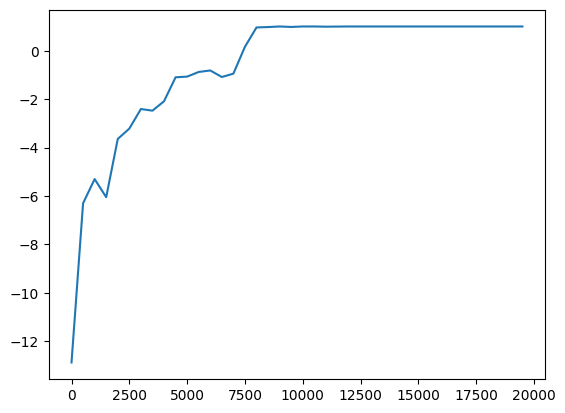

Testing


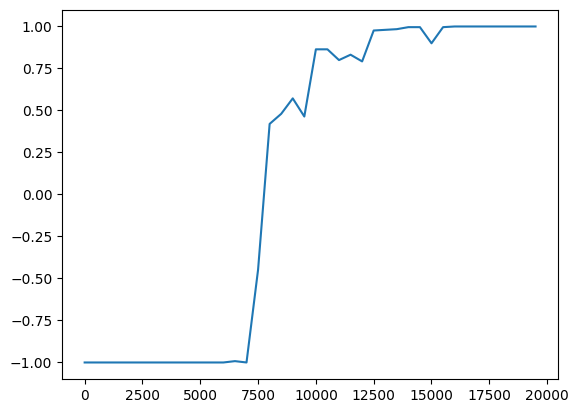

In [27]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
env = gym.make('CliffWalking-v1', render_mode="rgb_array")

epsilon = 1
q_table = np.zeros((env.observation_space.n, env.action_space.n))
step_size = 0.2
discount = 0.95
episodes = 20000
lam = 0
found = -1
test = []
train = []

def show_ep():
    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

for ep in range(episodes):
    done = False
    if found>-1:
        epsilon -= (2/(episodes-found))*epsilon
    obs, info = env.reset()
    step = 0

    while not done:
        if step>0:
            # state, action, reward
            save_info = (last_state, action, reward)
        step += 1
        last_state = obs

        action = (env.action_space.sample() if np.random.rand()<epsilon else np.argmax(q_table[obs]))
        obs, reward, terminated, truncated, info = env.step(action)
        truncated = True if step>100 else truncated
        done = truncated or terminated
        if obs==47:
            reward = 1

        if done:
            q_table[last_state][action] += step_size* (reward - q_table[last_state][action])
            q_table[save_info[0]][save_info[1]] += step_size* (save_info[2] - q_table[save_info[0]][save_info[1]])
            train.append(reward)
            if reward>0:
                found = ep
            #show_ep()
            if ep%100==0:
                print(ep,step,reward)
            break
        elif step>1:
            q_table[save_info[0]][save_info[1]] += step_size* (save_info[2] + discount*(q_table[last_state][action]) - q_table[save_info[0]][save_info[1]])

    obs, info = env.reset()
    done = False
    step = 0
    while not done:
        step += 1
        obs, reward, terminated, truncated, info = env.step(np.argmax(q_table[obs]))
        #if obs!=0:
            #print(obs)
        if obs==47:
            reward = 1
        truncated = True if step>100 else truncated
        done = truncated or terminated
        if done:
            test.append(reward)
            break

print('Training')
window = 500
x = range(0,episodes,window)
avg_train = [float(np.mean(train[i:i+window])) for i in x]
plt.plot(x,avg_train)
plt.show()

print('Testing')
avg_test = [float(np.mean(test[i:i+window])) for i in x]
plt.plot(x,avg_test)
plt.show()

#print(q_table)